# Aggregazione Auto per Regione
Script per aggregare i dati delle auto per provincia in dati per regione

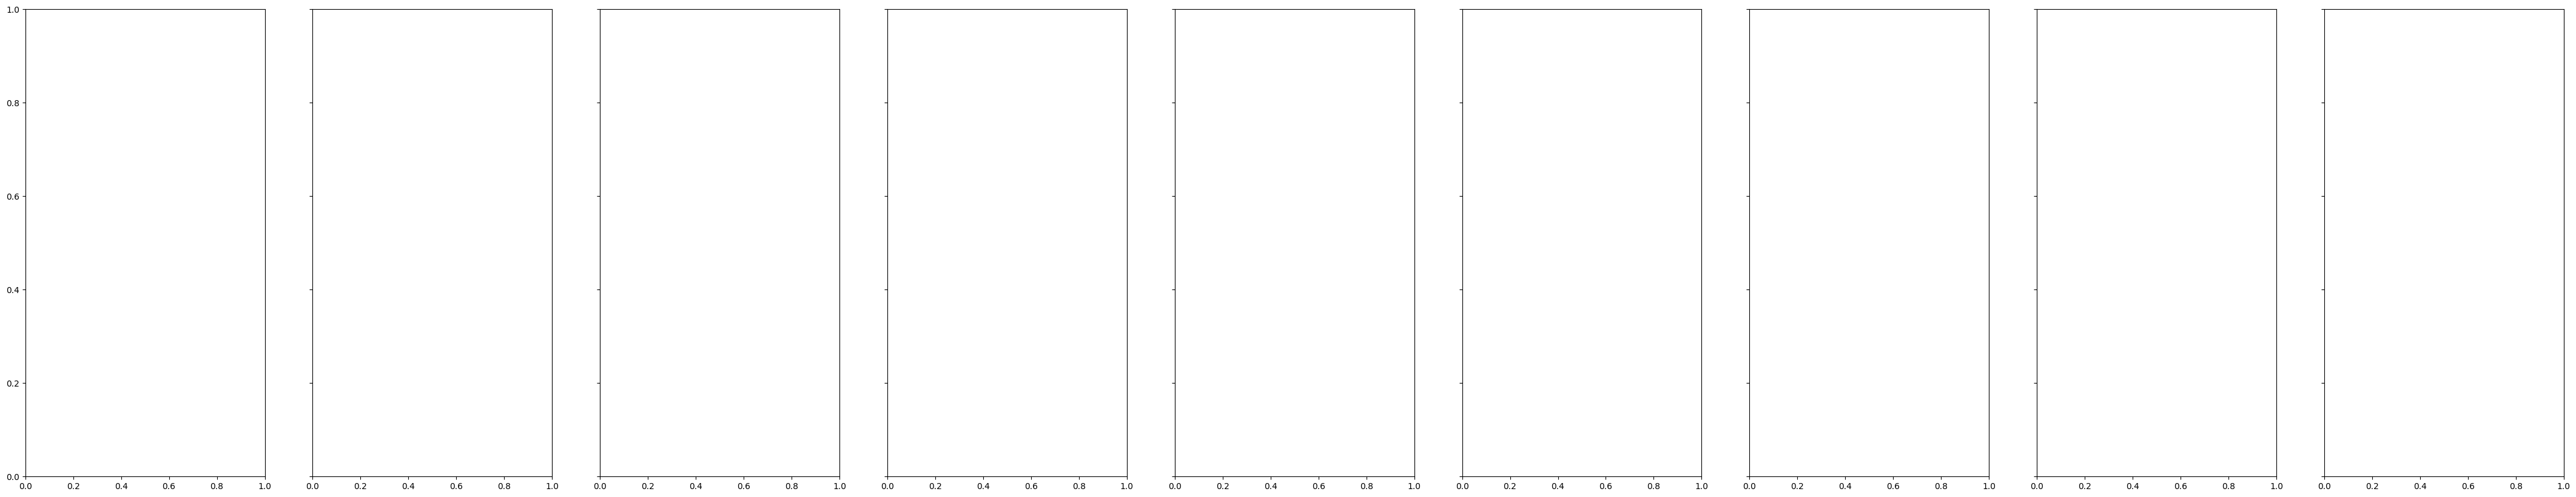

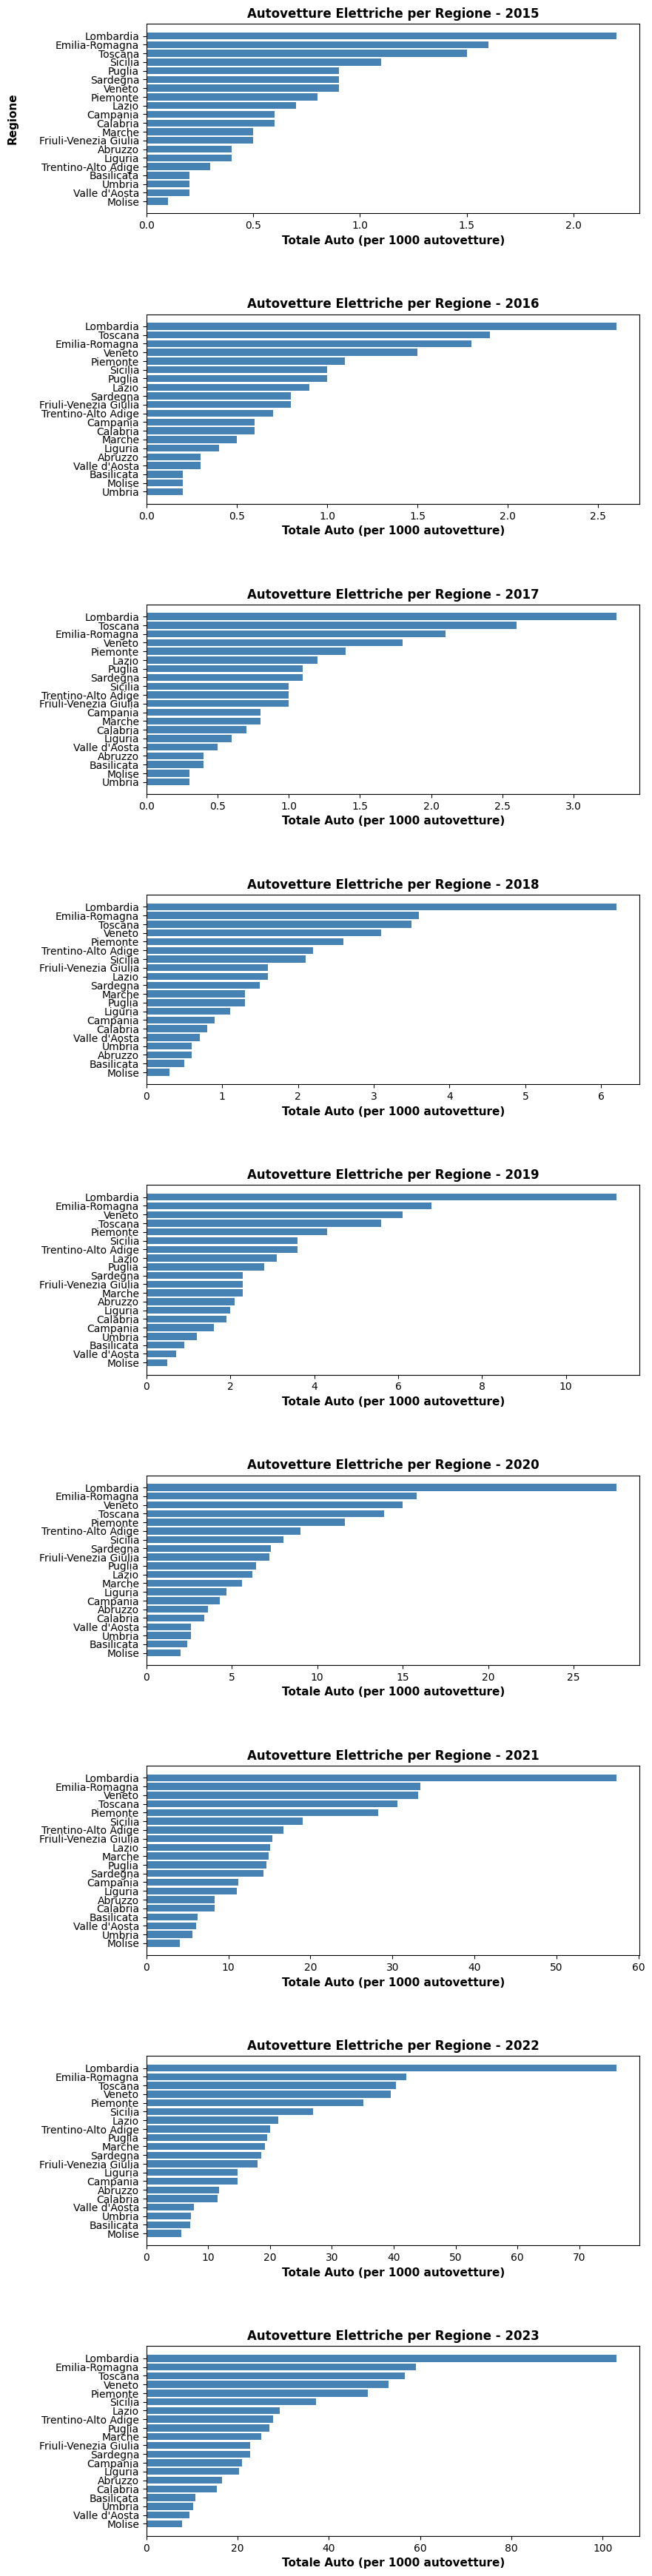

<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


# CARICA IL CSV
df = pd.read_csv('../data/csv/auto_elettr_su_1000.csv')

# VALORI DA ESCLUDERE
valori_da_escludere = [
    'Italia', 'Nord', 'Nord-ovest', 'Nord-est', 'Centro', 'Sud', 'Mezzogiorno', 'Isole',
    'Capoluoghi di città metropolitana', 'Capoluoghi di provincia'
]

# MAPPING PROVINCIA -> REGIONE
provincia_regione = {
# Piemonte
'Torino': 'Piemonte', 'Vercelli': 'Piemonte', 'Novara': 'Piemonte', 'Cuneo': 'Piemonte',
'Asti': 'Piemonte', 'Alessandria': 'Piemonte', 'Biella': 'Piemonte', 'Verbania': 'Piemonte',

# Valle d'Aosta
'Aosta': "Valle d'Aosta",

# Liguria
'Imperia': 'Liguria', 'Savona': 'Liguria', 'Genova': 'Liguria', 'La Spezia': 'Liguria',

# Lombardia
'Varese': 'Lombardia', 'Como': 'Lombardia', 'Lecco': 'Lombardia', 'Sondrio': 'Lombardia',
'Milano': 'Lombardia', 'Bergamo': 'Lombardia', 'Brescia': 'Lombardia', 'Pavia': 'Lombardia',
'Cremona': 'Lombardia', 'Mantova': 'Lombardia', 'Monza': 'Lombardia', 'Lodi': 'Lombardia',

# Trentino-Alto Adige
'Bolzano/Bozen': 'Trentino-Alto Adige', 'Trento': 'Trentino-Alto Adige',

# Veneto
'Belluno': 'Veneto', 'Treviso': 'Veneto', 'Venezia': 'Veneto', 'Padova': 'Veneto',
'Rovigo': 'Veneto', 'Verona': 'Veneto', 'Vicenza': 'Veneto',

# Friuli-Venezia Giulia
'Pordenone': 'Friuli-Venezia Giulia', 'Udine': 'Friuli-Venezia Giulia',
'Gorizia': 'Friuli-Venezia Giulia', 'Trieste': 'Friuli-Venezia Giulia',

# Emilia-Romagna
'Piacenza': 'Emilia-Romagna', 'Parma': 'Emilia-Romagna', 'Reggio nell\'Emilia': 'Emilia-Romagna',
'Modena': 'Emilia-Romagna', 'Bologna': 'Emilia-Romagna', 'Ferrara': 'Emilia-Romagna',
'Ravenna': 'Emilia-Romagna', 'Forlì': 'Emilia-Romagna', 'Cesena': 'Emilia-Romagna',
'Rimini': 'Emilia-Romagna',

# Toscana
'Massa': 'Toscana', 'Lucca': 'Toscana', 'Pistoia': 'Toscana', 'Firenze': 'Toscana',
'Prato': 'Toscana', 'Livorno': 'Toscana', 'Pisa': 'Toscana', 'Arezzo': 'Toscana',
'Siena': 'Toscana', 'Grosseto': 'Toscana',

# Umbria
'Perugia': 'Umbria', 'Terni': 'Umbria',

# Marche
'Pesaro': 'Marche', 'Ancona': 'Marche', 'Macerata': 'Marche', 'Ascoli Piceno': 'Marche',
'Fermo': 'Marche',

# Lazio
'Viterbo': 'Lazio', 'Rieti': 'Lazio', 'Roma': 'Lazio', 'Frosinone': 'Lazio', 'Latina': 'Lazio',

# Abruzzo
'L\'Aquila': 'Abruzzo', 'Teramo': 'Abruzzo', 'Pescara': 'Abruzzo', 'Chieti': 'Abruzzo',

# Molise
'Campobasso': 'Molise', 'Isernia': 'Molise',

# Campania
'Caserta': 'Campania', 'Benevento': 'Campania', 'Napoli': 'Campania', 'Avellino': 'Campania',
'Salerno': 'Campania',

# Puglia
'Foggia': 'Puglia', 'Bari': 'Puglia', 'Taranto': 'Puglia', 'Brindisi': 'Puglia',
'Lecce': 'Puglia', 'Andria': 'Puglia', 'Barletta': 'Puglia', 'Trani': 'Puglia',

# Basilicata
'Potenza': 'Basilicata', 'Matera': 'Basilicata',

# Calabria
'Cosenza': 'Calabria', 'Catanzaro': 'Calabria', 'Reggio di Calabria': 'Calabria',
'Crotone': 'Calabria', 'Vibo Valentia': 'Calabria',

# Sicilia
'Palermo': 'Sicilia', 'Trapani': 'Sicilia', 'Agrigento': 'Sicilia', 'Caltanissetta': 'Sicilia',
'Enna': 'Sicilia', 'Catania': 'Sicilia', 'Ragusa': 'Sicilia', 'Siracusa': 'Sicilia',
'Messina': 'Sicilia',

# Sardegna
'Sassari': 'Sardegna', 'Nuoro': 'Sardegna', 'Oristano': 'Sardegna', 'Cagliari': 'Sardegna',
'Carbonia': 'Sardegna',
}
# FILTRA SOLO PROVINCE
df_province = df[~df['Frequenza'].isin(valori_da_escludere)].copy()

# AGGIUNGI COLONNA REGIONE (QUI USI df_province)
df_province['Regione'] = df_province['Frequenza'].map(provincia_regione)

# TIENI SOLO RIGHE CON REGIONE VALIDA
df_con_regioni = df_province[df_province['Regione'].notna()].copy()

# CONVERTI INDICATORE A NUMERICO
df_con_regioni['Valore_Numerico'] = pd.to_numeric(df_con_regioni['Indicatore'], errors='coerce')

# PRENDI TUTTI GLI ANNI DISPONIBILI (dal 2015 in poi)
anni = sorted(df_con_regioni['DATA_TYPE'].unique())
anni = [a for a in anni if a >= 2015]

# CREA UN SUBPLOT PER OGNI ANNO
n_anni = len(anni)
fig, axes = plt.subplots(1, n_anni, figsize=(6*n_anni, 10), sharey=True)

# SE C'È SOLO UN ANNO, axes NON È UNA LISTA
# CREA UN SUBPLOT PER OGNI ANNO (1 PER RIGA)
n_anni = len(anni)
fig, axes = plt.subplots(n_anni, 1, figsize=(10, 4*n_anni), sharex=False)

# SE C'È SOLO UN ANNO, axes NON È UNA LISTA
if n_anni == 1:
    axes = [axes]

for ax, anno in zip(axes, anni):
    df_anno = (
        df_con_regioni[df_con_regioni['DATA_TYPE'] == anno]
        .groupby('Regione')['Valore_Numerico']
        .sum()
        .reset_index()
        .sort_values('Valore_Numerico', ascending=False)
    )

    ax.barh(df_anno['Regione'], df_anno['Valore_Numerico'], color='steelblue')
    ax.set_xlabel('Totale Auto (per 1000 autovetture)', fontsize=11, fontweight='bold')
    ax.set_title(f'Autovetture Elettriche per Regione - {anno}', fontsize=12, fontweight='bold')
    ax.invert_yaxis()

axes[0].set_ylabel('Regione', fontsize=11, fontweight='bold', labelpad=20)

plt.tight_layout(pad=5)

for ax, anno in zip(axes, anni):
    df_anno = (
        df_con_regioni[df_con_regioni['DATA_TYPE'] == anno]
        .groupby('Regione')['Valore_Numerico']
        .sum()
        .reset_index()
        .sort_values('Valore_Numerico', ascending=False)
    )

    ax.barh(df_anno['Regione'], df_anno['Valore_Numerico'], color='steelblue')
    ax.set_xlabel('Totale Auto (per 1000 autovetture)', fontsize=11, fontweight='bold')
    ax.set_title(f'Autovetture Elettriche per Regione - {anno}', fontsize=12, fontweight='bold')
    ax.invert_yaxis()

axes[0].set_ylabel('Regione', fontsize=11, fontweight='bold', labelpad=20)

plt.tight_layout(pad=5)
plt.show()
